In [5]:
import pandas as pd
import matplotlib.pyplot as plt

funds = pd.read_csv('backend/data/funds.csv')
metrics = pd.read_csv('backend/data/fund_metrics.csv')

funds = funds.drop(columns=['expense_ratio_pct', 'aum_usd_bn', 'dividend_yield_pct'], errors='ignore')
df = funds.merge(metrics, on='ticker', how='left')

RISK_FREE_RATE = 4.5
has_both = df['return_1y_pct'].notna() & df['volatility_1y_pct'].notna() & (df['volatility_1y_pct'] != 0)
df['sharpe_ratio_1y'] = (df['return_1y_pct'] - RISK_FREE_RATE) / df['volatility_1y_pct']
df.loc[~has_both, 'sharpe_ratio_1y'] = None

df.head()

,ticker,fund_name,asset_class,category,as_of_date,ytd_return_pct,return_1y_pct,return_3y_ann_pct,volatility_1y_pct,max_drawdown_1y_pct,expense_ratio_pct,aum_usd_bn,dividend_yield_pct,data_completeness_score,sharpe_ratio_1y
0,VTI,Vanguard Total Stock Market ETF,US Equity,Broad Market,2026-04-14,8.7,17.2,10.8,14.6,-8.9,0.03,410,1.3,90,0.869863
1,VOO,Vanguard S&P 500 ETF,US Equity,Large Cap Blend,2026-04-14,9.1,18.0,11.5,13.9,-8.1,0.03,520,1.2,100,0.971223
2,QQQ,Invesco QQQ Trust,US Equity,Large Cap Growth,2026-04-14,11.8,24.6,14.7,19.8,-11.7,0.20,260,0.6,95,1.015152
3,VT,Vanguard Total World Stock ETF,Global Equity,Broad Market,2026-04-14,7.2,14.8,9.1,13.7,-8.5,0.07,43,1.8,95,0.751825
4,VXUS,Vanguard Total International Stock ETF,International Equity,Broad Market ex-US,2026-04-14,5.3,11.6,6.9,14.1,-9.4,0.07,85,2.7,90,0.503546


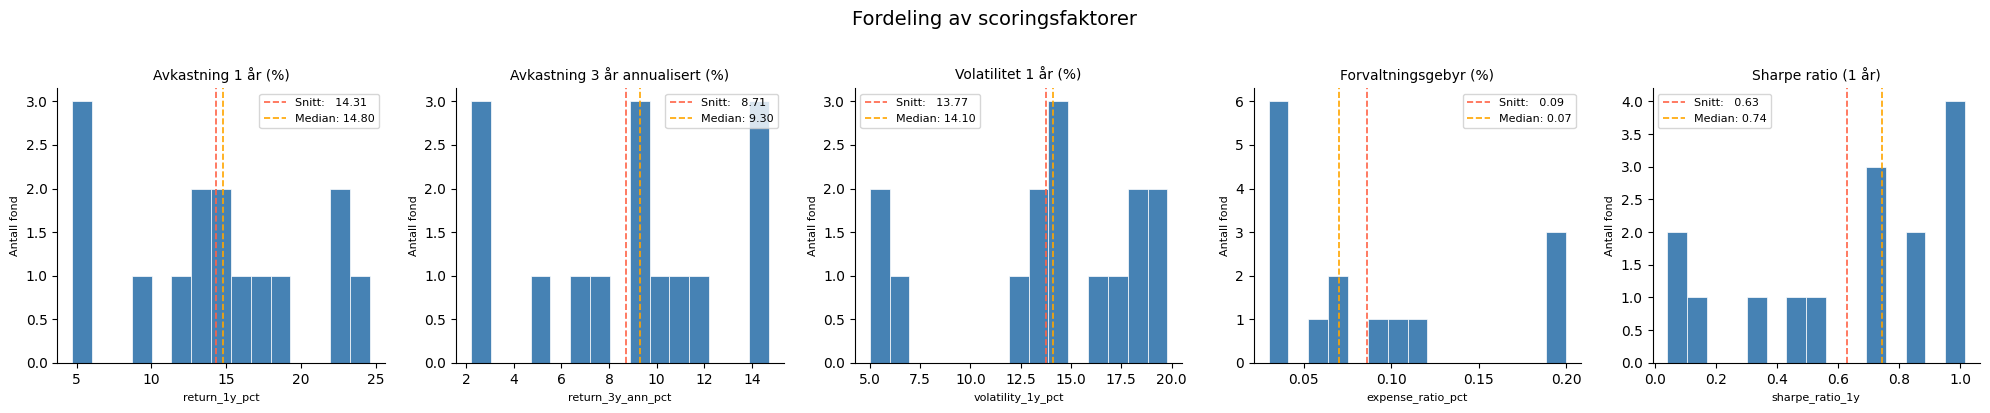

In [6]:
SCORING_FEATURES = {
    'return_1y_pct':      'Avkastning 1 år (%)',
    'return_3y_ann_pct':  'Avkastning 3 år annualisert (%)',
    'volatility_1y_pct':  'Volatilitet 1 år (%)',
    'expense_ratio_pct':  'Forvaltningsgebyr (%)',
    'sharpe_ratio_1y':    'Sharpe ratio (1 år)',
}

fig, axes = plt.subplots(1, len(SCORING_FEATURES), figsize=(20, 4))
fig.suptitle('Fordeling av scoringsfaktorer', fontsize=14, y=1.02)

for ax, (col, label) in zip(axes, SCORING_FEATURES.items()):
    data = df[col].dropna()
    ax.hist(data, bins=15, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.axvline(data.mean(),   color='tomato',  linestyle='--', linewidth=1.2, label=f'Snitt:   {data.mean():.2f}')
    ax.axvline(data.median(), color='orange',  linestyle='--', linewidth=1.2, label=f'Median: {data.median():.2f}')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('Antall fond', fontsize=8)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [7]:
print('Deskriptiv statistikk for scoringsfaktorer:')
df[list(SCORING_FEATURES.keys())].describe().round(2)

Deskriptiv statistikk for scoringsfaktorer:


,return_1y_pct,return_3y_ann_pct,volatility_1y_pct,expense_ratio_pct,sharpe_ratio_1y
count,15.00,15.00,15.00,15.00,15.00
mean,14.31,8.71,13.77,0.09,0.63
std,6.37,4.16,4.85,0.06,0.35
min,4.70,2.20,5.00,0.03,0.04
25%,10.60,6.00,12.70,0.04,0.38
50%,14.80,9.30,14.10,0.07,0.74
75%,17.60,11.15,17.50,0.11,0.92
max,24.60,14.70,19.80,0.20,1.02


/var/folders/b_/8ktp999n33bd4063_2mkrvp40000gn/T/ipykernel_9903/2143595169.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: ((g['weight_pct'] / 100) ** 2).sum())


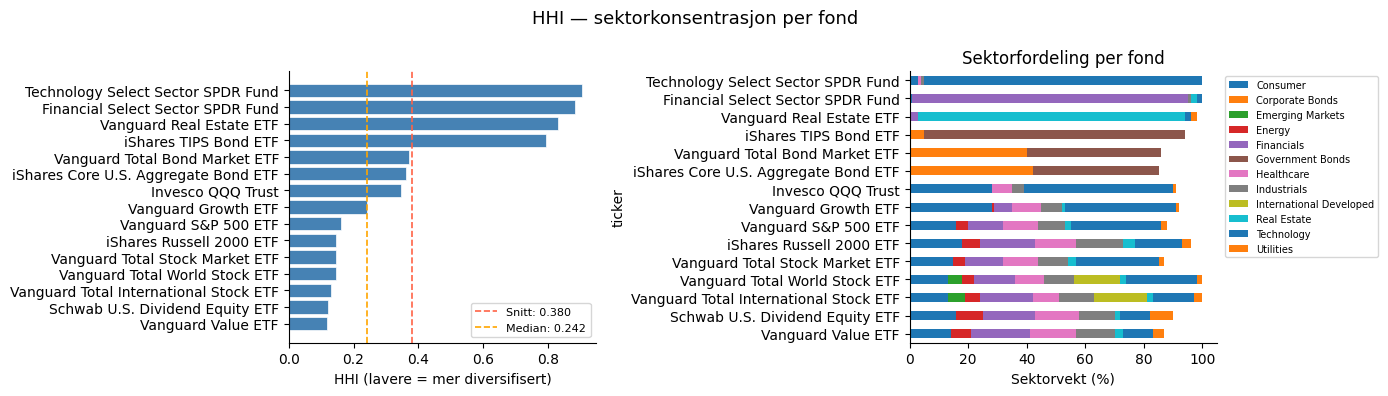


Deskriptiv statistikk — HHI:


count    15.0000
mean      0.3799
std       0.3088
min       0.1195
25%       0.1448
50%       0.2416
75%       0.5831
max       0.9036
Name: hhi, dtype: float64

In [8]:

# --- Diversifisering: HHI per fond ---
sector = pd.read_csv('backend/data/fund_sector_exposure.csv')
sector['weight_pct'] = pd.to_numeric(sector['weight_pct'], errors='coerce')

hhi = (
    sector.groupby('ticker')
    .apply(lambda g: ((g['weight_pct'] / 100) ** 2).sum())
    .rename('hhi')
    .reset_index()
    .merge(funds[['ticker', 'fund_name']], on='ticker')
    .sort_values('hhi')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('HHI — sektorkonsentrasjon per fond', fontsize=13)

# Bar chart: HHI per fund
ax = axes[0]
ax.barh(hhi['fund_name'], hhi['hhi'], color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(hhi['hhi'].mean(), color='tomato', linestyle='--', linewidth=1.2, label=f"Snitt: {hhi['hhi'].mean():.3f}")
ax.axvline(hhi['hhi'].median(), color='orange', linestyle='--', linewidth=1.2, label=f"Median: {hhi['hhi'].median():.3f}")
ax.set_xlabel('HHI (lavere = mer diversifisert)')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# Stacked bar: sector breakdown per fund
pivot = sector.pivot_table(index='ticker', columns='sector', values='weight_pct', fill_value=0)
pivot = pivot.loc[hhi['ticker']]  # same order as hhi (sorted by HHI)
fund_labels = hhi.set_index('ticker')['fund_name']
pivot.index = pivot.index.map(fund_labels)
pivot.plot(kind='barh', stacked=True, ax=axes[1], legend=True)
axes[1].set_xlabel('Sektorvekt (%)')
axes[1].set_title('Sektorfordeling per fond')
axes[1].legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print('\nDeskriptiv statistikk — HHI:')
hhi['hhi'].describe().round(4)
